In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---

---

---

### PYTORCH TEST

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.12.0+cu130
True


In [3]:
# # Set device type
# device = "cuda" if torch.cuda.is_available() else "cpu"
# device

In [4]:
# !nvidia-smi

In [5]:
# from torch import nn # nn contains all of PyTorch's building blocks for neural networks

---

---

---

# DATASET UPLOAD

The Electricity dataset used in modern time series forecasting papers (e.g. TimesNet, Autoformer, Informer) originates from a single source, namely the UCI Electricity Load Diagrams dataset (available from 2015). This original dataset contains electricity consumption measurements for 370 clients, recorded every 15 minutes from 2011 to 2014. It includes real timestamps and reflects raw, unprocessed data, with significant sparsity due to inactive or late-starting clients.

From this raw dataset, a standard benchmark version was introduced in the work of Lai et al. (Modeling Long- and Short-Term Temporal Patterns with Deep Neural Networks - 2017). In this preprocessing pipeline, the data undergoes several transformations. First, a temporal subset is selected, typically covering the period from 2012 to 2014. Then, clients with excessive zero values or missing activity are removed, reducing the number of variables from 370 to 321. The temporal resolution is changed by aggregating the data from 15-minute intervals to hourly intervals, effectively combining every four consecutive measurements into one. The resulting dataset contains 26,304 time steps, corresponding to approximately three years of hourly data. Importantly, in this benchmark version the timestamp column is removed, and the dataset is represented purely as a matrix of shape $T \times N$.

This processed dataset from Lai et al. became the de facto benchmark used in many subsequent works. However, since it lacks explicit timestamps, later libraries and implementations reintroduce a time axis artificially. In particular, the version distributed with the TimesNet repository contains exactly the same numerical values as the Lai benchmark dataset, but includes an additional date column. These timestamps do not correspond to the original data. Instead, they are synthetically generated by assuming a fixed hourly frequency and assigning a new starting date (e.g. 2016–2019). This means that while the temporal spacing is correct (one-hour intervals), the absolute calendar dates are not meaningful.

Therefore, the dataset used in practice can be understood as having three conceptual layers. The first is the raw UCI dataset, which contains real timestamps, 15-minute resolution, and 370 clients. The second is the benchmark dataset introduced by Lai et al., which is hourly, filtered to 321 clients, spans 2012–2014, and has no timestamps. The third is the version used in modern repositories such as TimesNet, which retains the benchmark values but adds synthetic timestamps to facilitate the use of temporal features such as hour-of-day or day-of-week.

This distinction is important for interpretation. The time index in the benchmark dataset should be understood as a structured sequence with periodic properties, rather than a faithful representation of real-world calendar time. The preprocessing steps applied include temporal subsetting, removal of sparse series, aggregation from 15-minute to hourly resolution, and in some implementations, the addition of artificial timestamps. Despite these transformations, the dataset remains consistent across the literature in terms of numerical values and dimensionality, ensuring comparability between models.

For practical purposes, using the preprocessed dataset provided by repositories such as TimesNet is appropriate, as it matches the standard benchmark and includes the necessary structure for modern architectures.


from Lai et al:\
The raw dataset is in https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014. It is the electricity consumption in kWh was recorded every 15 minutes from 2011 to 2014. Because the some dimensions are equal to 0. So we eliminate the records in 2011. Final we get data contains electircity consumption of 321 clients from 2012 to 2014. And we converted the data to reflect hourly consumption. All datasets have been split into training set (60%), validation set (20%) and test set (20%) in chronological order

So let's analyze the preprocessed dataset given by the TimesNet github repo:

In [6]:
df = pd.read_csv("../electricity_dataset/electricity.csv")    # TimesNet version
df

,date,0,1,2,3,4,5,6,7,8,...,311,312,313,314,315,316,317,318,319,OT
0,2016-07-01 02:00:00,14.0,69.0,234.0,415.0,215.0,1056.0,29.0,840.0,226.0,...,676.0,372.0,80100.0,4719.0,5002.0,48.0,38.0,1558.0,182.0,2162.0
1,2016-07-01 03:00:00,18.0,92.0,312.0,556.0,292.0,1363.0,29.0,1102.0,271.0,...,805.0,452.0,95200.0,4643.0,6617.0,65.0,47.0,2177.0,253.0,2835.0
2,2016-07-01 04:00:00,21.0,96.0,312.0,560.0,272.0,1240.0,29.0,1025.0,270.0,...,817.0,430.0,96600.0,4285.0,6571.0,64.0,43.0,2193.0,218.0,2764.0
3,2016-07-01 05:00:00,20.0,92.0,312.0,443.0,213.0,845.0,24.0,833.0,179.0,...,801.0,291.0,94500.0,4222.0,6365.0,65.0,39.0,1315.0,195.0,2735.0
4,2016-07-01 06:00:00,22.0,91.0,312.0,346.0,190.0,647.0,16.0,733.0,186.0,...,807.0,279.0,91300.0,4116.0,6298.0,75.0,40.0,1378.0,191.0,2721.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2019-07-01 21:00:00,11.0,116.0,8.0,844.0,384.0,1590.0,51.0,1412.0,407.0,...,1897.0,1589.0,166500.0,9917.0,10412.0,324.0,21.0,1870.0,162.0,2773.0
26300,2019-07-01 22:00:00,11.0,103.0,8.0,749.0,371.0,1366.0,47.0,1265.0,369.0,...,1374.0,1336.0,158800.0,6812.0,8956.0,302.0,20.0,1506.0,438.0,2755.0
26301,2019-07-01 23:00:00,12.0,93.0,8.0,650.0,346.0,1282.0,48.0,1079.0,308.0,...,938.0,1311.0,154300.0,6602.0,5910.0,302.0,18.0,1864.0,621.0,2650.0
26302,2019-07-02 00:00:00,10.0,92.0,8.0,646.0,349.0,1261.0,48.0,1009.0,288.0,...,833.0,1227.0,141900.0,6546.0,5502.0,259.0,33.0,2623.0,783.0,2719.0


In [7]:
print("\n--- BASIC INFO ---")
print("shape:", df.shape)
print("columns (first 5):", df.columns[:5].tolist())
print("columns (last 5): ", df.columns[-5:].tolist())

# assume first column is datetime
time_col = df.columns[0]
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

if df[time_col].isna().any():
    print("WARNING: some timestamps could not be parsed")


--- BASIC INFO ---
shape: (26304, 322)
columns (first 5): ['date', '0', '1', '2', '3']
columns (last 5):  ['316', '317', '318', '319', 'OT']


In [8]:
# sort
df = df.sort_values(by=time_col).reset_index(drop=True)

# =========================
# TIME ANALYSIS
# =========================
print("\n--- TIME RESOLUTION ---")
time_diffs = df[time_col].diff().dropna()

print("most common time differences between two data:")
print(time_diffs.value_counts().head())
minutes = time_diffs.dt.total_seconds() / 60
print("\nsummary (minutes):")
print(minutes.describe())

# check regularity
most_common_diff = time_diffs.mode()[0]
irregular = (time_diffs != most_common_diff).sum()

print("\n--- TIME REGULARITY ---")
print("expected step:", most_common_diff)
print("irregular steps:", irregular)

# check missing timestamps
full_range = pd.date_range(
    start=df[time_col].iloc[0],
    end=df[time_col].iloc[-1],
    freq=most_common_diff
)
missing_timestamps = len(full_range) - len(df)

print("\nmissing timestamps:", missing_timestamps)

print("\n--- TIME RANGE ---")
print("start:", df[time_col].iloc[0])
print("end:  ", df[time_col].iloc[-1])


--- TIME RESOLUTION ---
most common time differences between two data:
date
0 days 01:00:00    26303
Name: count, dtype: int64

summary (minutes):
count    26303.0
mean        60.0
std          0.0
min         60.0
25%         60.0
50%         60.0
75%         60.0
max         60.0
Name: date, dtype: float64

--- TIME REGULARITY ---
expected step: 0 days 01:00:00
irregular steps: 0

missing timestamps: 0

--- TIME RANGE ---
start: 2016-07-01 02:00:00
end:   2019-07-02 01:00:00


In [9]:
# =========================
# NUMERICAL DATA
# =========================
data = df.drop(columns=[time_col])

print("\n--- MISSING VALUES ---")
total_nans = data.isna().sum().sum()
print("total NaNs:", total_nans)


--- MISSING VALUES ---
total NaNs: 0


In [10]:
# =========================
# ZERO ANALYSIS
# =========================
print("\n--- ZERO ANALYSIS ---")

# COLUMNS:
zero_per_col = (data == 0).sum() # counts the total number of zeros in each column
zero_ratio_col = zero_per_col / len(data)

print("columns with >30% zeros:", (zero_ratio_col > 0.3).sum())
print("top 10 zero-ratio columns:")
print(zero_ratio_col.sort_values(ascending=False).head(10))

# ROWS:
zero_per_row = (data == 0).sum(axis=1) # count how many zeros exist in each individual row
zero_ratio_row = zero_per_row / data.shape[1]

print("rows with >30% zeros:", (zero_ratio_row > 0.3).sum())
print("top 10 zero-ratio rows:")
print(zero_ratio_row.sort_values(ascending=False).head(10))


--- ZERO ANALYSIS ---
columns with >30% zeros: 6
top 10 zero-ratio columns:
182    0.757109
298    0.606790
105    0.540336
107    0.504068
299    0.463390
106    0.439363
57     0.088922
245    0.019883
118    0.006235
2      0.005665
dtype: float64
rows with >30% zeros: 3
top 10 zero-ratio rows:
19657    0.682243
2017     0.629283
10921    0.626168
26142    0.077882
26141    0.077882
26140    0.077882
26138    0.077882
26137    0.077882
26155    0.077882
26154    0.077882
dtype: float64


In [11]:
# =========================
# GLOBAL STATS
# =========================
print("\n--- GLOBAL STATS ---")
print("mean:", data.values.mean())
print("std:", data.values.std())
print("min:", data.values.min())
print("max:", data.values.max())


--- GLOBAL STATS ---
mean: 2538.7916483095332
std: 15027.570159457542
min: 0.0
max: 764000.0


In [13]:
# =========================
# PER-SERIES 
# =========================
print("\n--- PER-SERIES STATS ---")

means = data.mean()
stds = data.std()

print("mean (across series):")
print(means.describe())

print("\nstd (across series):")
print(stds.describe())

# check scale heterogeneity
print("\nscale ratio (max std / min std):", stds.max() / (stds.min() + 1e-8))


--- PER-SERIES STATS ---
mean (across series):
count       321.000000
mean       2538.791648
std       12479.287203
min          10.627395
25%         288.346487
50%         591.950388
75%        1425.515891
max      200529.124848
dtype: float64

std (across series):
count       321.000000
mean       1139.743890
std        8336.701030
min           8.541949
25%         105.847978
50%         206.609137
75%         522.723835
max      146054.610575
dtype: float64

scale ratio (max std / min std): 17098.510570966617


In [14]:
# =========================
# CORRELATION
# =========================
print("\n--- CORRELATION (sample) ---")

sample_cols = data.columns[:50]  # avoid huge matrix
corr = data[sample_cols].corr()

print("mean abs correlation:", np.abs(corr.values).mean())


--- CORRELATION (sample) ---
mean abs correlation: 0.5086340014545753


In [15]:
# =========================
# SIMPLE SEASONALITY CHECK
# =========================
print("\n--- HOURLY SEASONALITY CHECK ---")

df['hour'] = df[time_col].dt.hour
hourly_mean = data.groupby(df['hour']).mean()

print("computed mean consumption per hour (shape):", hourly_mean.shape)


--- HOURLY SEASONALITY CHECK ---
computed mean consumption per hour (shape): (24, 321)



--- PLOTS ---


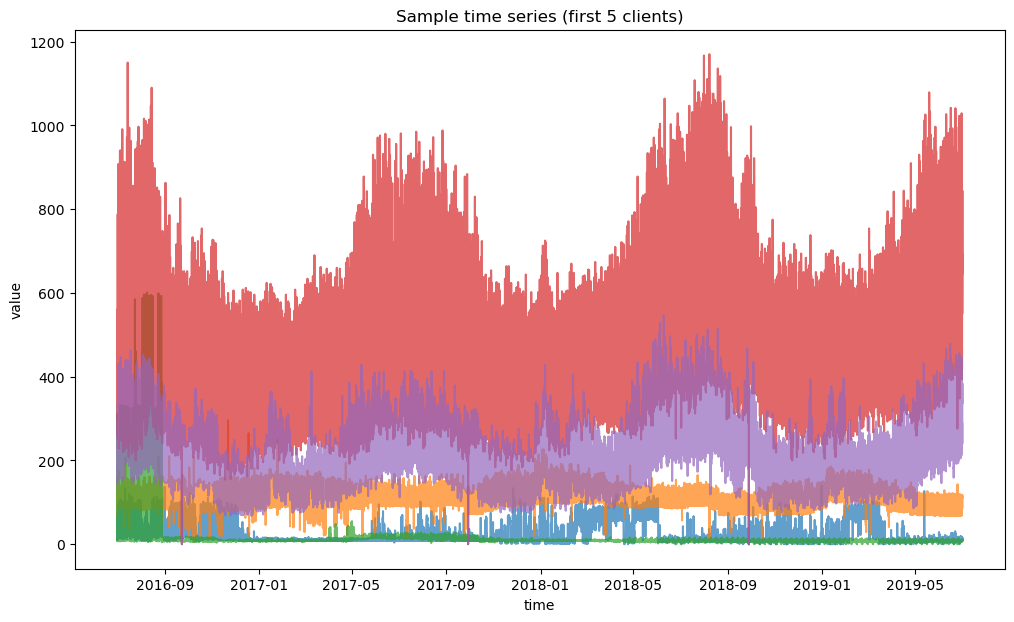

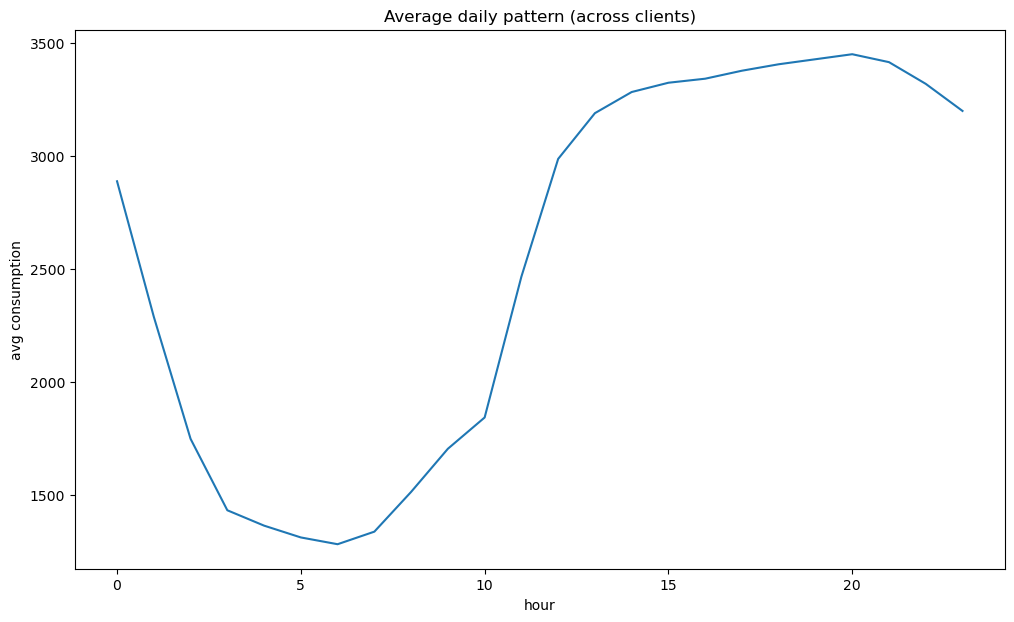

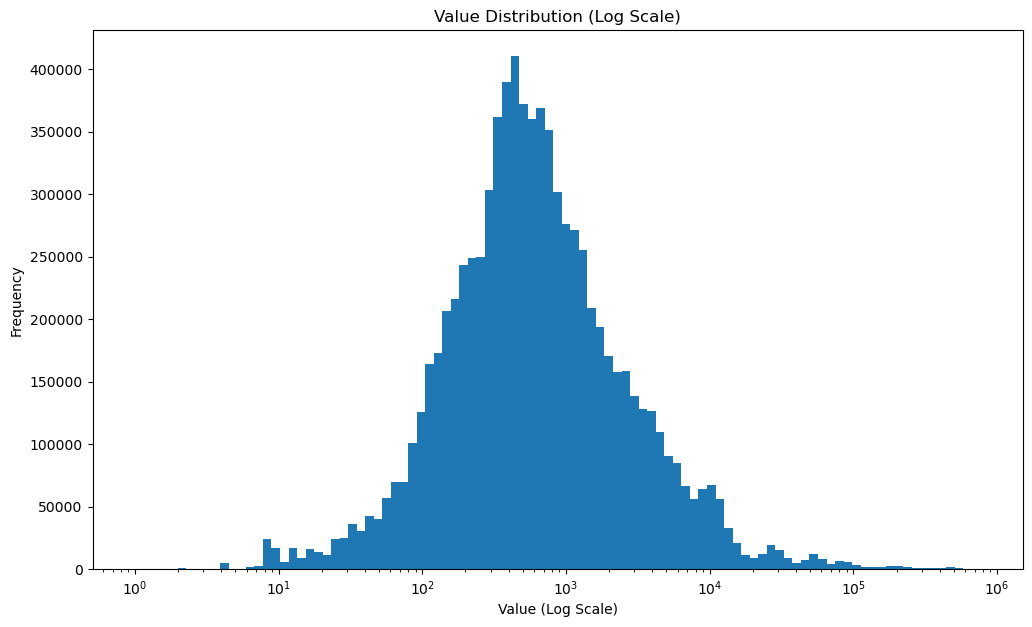


===== END =====



In [22]:
# =========================
# PLOTS
# =========================

print("\n--- PLOTS ---")

# plot few time series
plt.figure(figsize=(12,7))
for col in data.columns[:5]:
    plt.plot(df[time_col], data[col], alpha=0.7)
plt.title("Sample time series (first 5 clients)")
plt.xlabel("time")
plt.ylabel("value")
plt.show()

# hourly seasonality
plt.figure(figsize=(12,7))
plt.plot(hourly_mean.mean(axis=1))
plt.title("Average daily pattern (across clients)")
plt.xlabel("hour")
plt.ylabel("avg consumption")
plt.show()

# distribution
# Flatten data and remove non-positive values (log scale requires values > 0)
flat_data = data.values.flatten()
positive_data = flat_data[flat_data > 0]

# Define logarithmically spaced bins between the min and max values
bins = np.logspace(
    np.log10(positive_data.min()), 
    np.log10(positive_data.max()), 
    100
)

plt.figure(figsize=(12, 7))
plt.hist(positive_data, bins=bins)
plt.xscale('log')
plt.title("Value Distribution (Log Scale)")
plt.xlabel("Value (Log Scale)")
plt.ylabel("Frequency")
plt.show()

print("\n===== END =====\n")

In [ ]:
Total train samples found: 18221
Total val samples found: 2535
Total test samples found: 5167


In [3]:
18221 + 2535 +  5167

25923

In [2]:
18317 + 2633 + 5261

26211